<div style="text-align: center;">
    <img src="https://user-images.githubusercontent.com/86345471/221379942-51f24819-1f76-4289-8dee-06ea69f730f6.png" alt=Main "KPI />
</di>

**Завдання:** На довільному датасеті дослідити роботу DBSCAN і A/B тестування https://www.kaggle.com/datasets?search=security.

**Теорія:** Маючи справу з просторовими кластерами рiзної щiльностi, розмiру та форми, часто складно виявити групу точок. Завдання може бути ще складнiшим, якщо данi мiстять шум i викиди. Для роботи з великими просторовими базами даних був запропонований метод DBSCAN (Density-based spatial clustering of applications with noise, густинний алгоритм просторової кластеризацiї з наявнiстю шуму), що, як випливає з назви, оперує щiльнiстю даних. Як вхiднi параметри вiн потребує радiус e-околицi й кiлькiсть сусiдiв.

A/B-тестування, також відоме як спліт-тестування, передбачає порівняння двох версій змінної (A та B), щоб визначити, яка з них ефективніша за певним показником. У сфері машинного навчання ці змінні часто виявляються як різні моделі, алгоритми, набори функцій або гіперпараметри. Мета полягає в тому, щоб експериментально визначити, яка варіація веде до кращих результатів, чи то вища точність, краще залучення користувачів, збільшення продажів або будь-який інший відповідний показник ефективності.

<hr>

### 1. Імпорт бібліотек та алгоритмів

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from scipy import stats

from kneed import KneeLocator
from bioinfokit.visuz import cluster
from collections import Counter

### 2. Завантаження та огляд даних

In [42]:
df = pd.read_csv('./dataset.csv') # https://www.kaggle.com/datasets/xwolf12/malicious-and-benign-websites
df.shape

(1781, 21)

In [43]:
df.sample(5)

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,CONTENT_LENGTH,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,...,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
235,B0_215,33,8,UTF-8,mw2114.codfw.wmnet,NaN,US,CA,13/01/2001 0:12,12/12/2015 10:16,...,11,6,3694,40,32,11543,4286,40,8.0,0
1488,B0_1389,80,15,UTF-8,NaN,NaN,US,CA,9/01/1998 0:00,4/01/2017 0:00,...,0,0,0,0,0,0,0,0,0.0,0
1020,B0_230,54,10,ISO-8859-1,cloudflare-nginx,18952.0,US,CA,29/09/2005 0:00,5/05/2016 0:00,...,12,8,99843,1198,1284,2060012,100151,1198,4.0,0
917,B0_708,50,14,iso-8859-1,NaN,NaN,US,CA,9/01/1998 0:00,4/01/2017 0:00,...,2,5,1849,26,22,26589,2279,26,6.0,0
1373,B0_2283,70,13,UTF-8,nginx,NaN,PA,PANAMA,11/11/2007 0:00,18/12/2015 0:00,...,13,2,1688,16,12,742,1688,16,0.0,0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1781 non-null   object 
 1   URL_LENGTH                 1781 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 3   CHARSET                    1774 non-null   object 
 4   SERVER                     1605 non-null   object 
 5   CONTENT_LENGTH             969 non-null    float64
 6   WHOIS_COUNTRY              1475 non-null   object 
 7   WHOIS_STATEPRO             1419 non-null   object 
 8   WHOIS_REGDATE              1654 non-null   object 
 9   WHOIS_UPDATED_DATE         1642 non-null   object 
 10  TCP_CONVERSATION_EXCHANGE  1781 non-null   int64  
 11  DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 12  REMOTE_IPS                 1781 non-null   int64  
 13  APP_BYTES                  1781 non-null   int64

### 3. Попередня обробка даних для алгоритму DBSCAN¶

* <u>Вибір необхідних ознак</u>

In [45]:
df_withouttype = df.drop(['Type'], axis = 1)
df_cleaned = df_withouttype.dropna()
df_cleaned.shape

(636, 20)

* <u>Кодування текстових значень</u>

In [46]:
encoder = LabelEncoder()
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df_cleaned.loc[:, col] = encoder.fit_transform(df_cleaned[col])
df_cleaned.shape

(636, 20)

* <u>Зменшення розмірності методом PCA</u>

In [47]:
pca_scores = PCA().fit_transform(df_cleaned)
df_pc = pd.DataFrame(pca_scores)

* <u>Представлення t-SNE з вибірки PCA</u>

In [50]:
tsne_em = TSNE(n_components = 2, perplexity = 30.0, early_exaggeration = 12, 
               max_iter = 1000, learning_rate = 368, verbose = 1).fit_transform(df_pc.loc[:,0:49])

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 636 samples in 0.002s...
[t-SNE] Computed neighbors for 636 samples in 0.034s...
[t-SNE] Computed conditional probabilities for sample 636 / 636
[t-SNE] Mean sigma: 413.473974
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.596840
[t-SNE] KL divergence after 1000 iterations: 0.235465


* <u>Візуалізація кластерів t-SNE</u>

In [49]:
cluster.tsneplot(score=tsne_em)

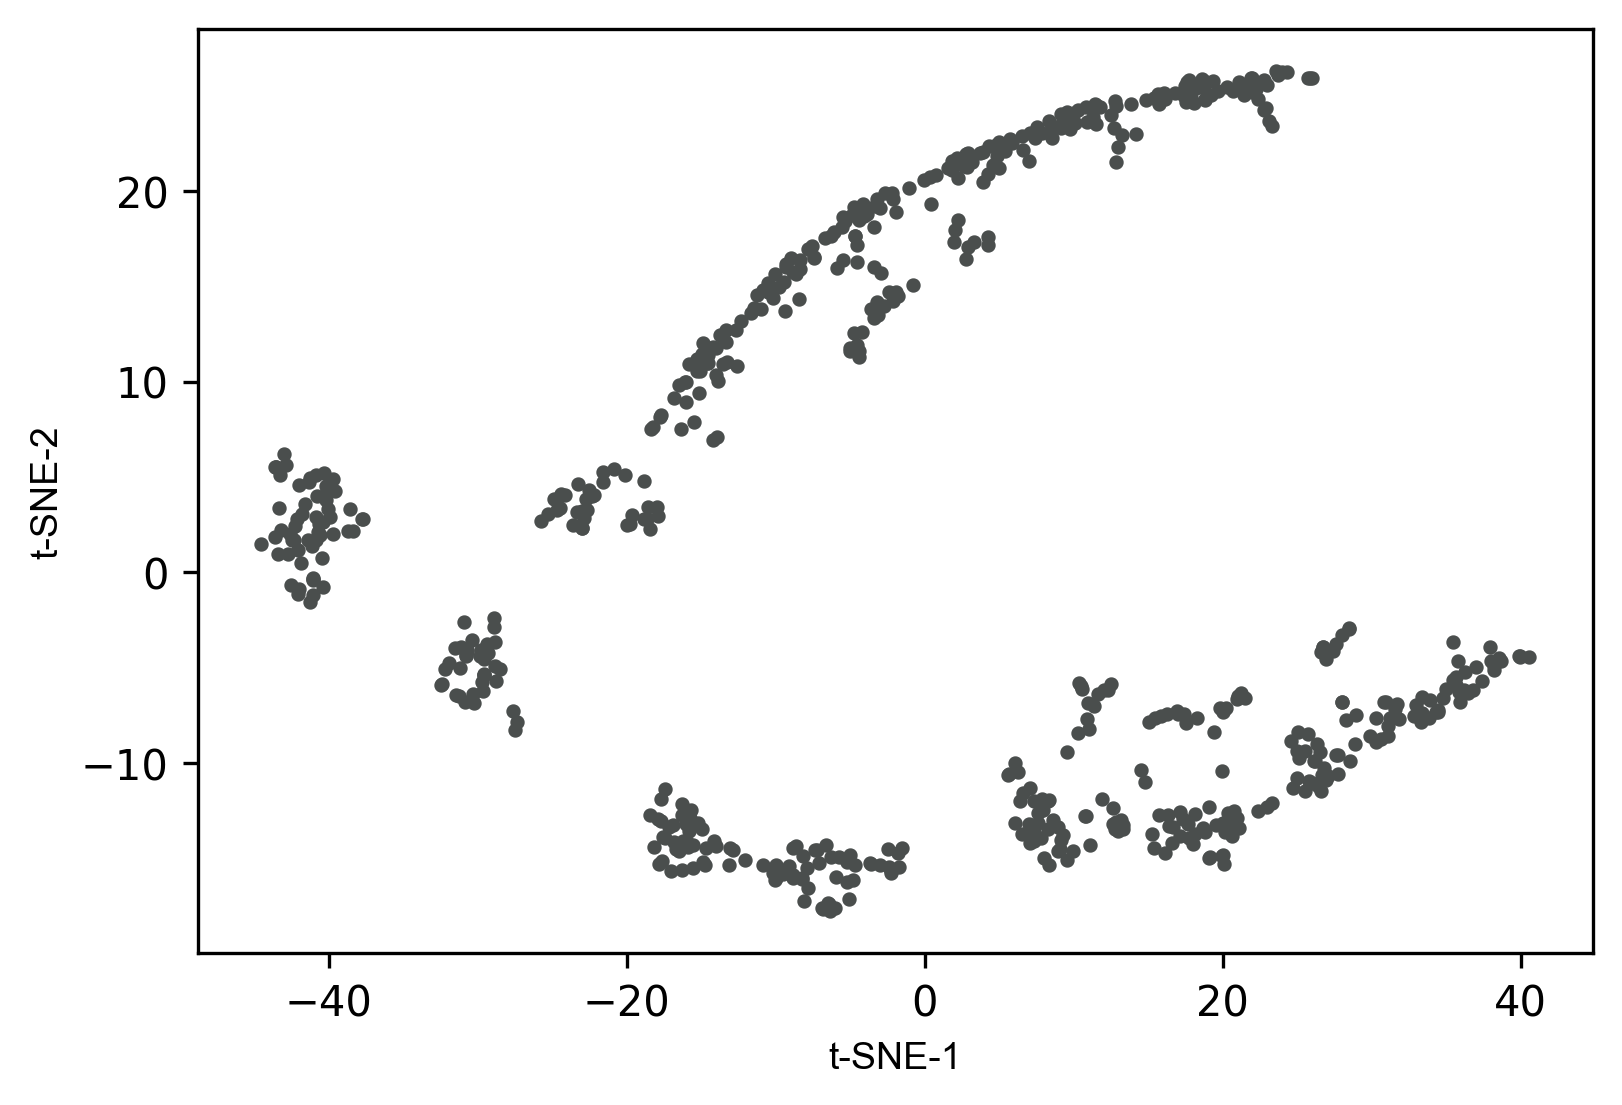

### 4. Реалізація кластеризації DBSCAN

* <u>Знаходження найкращого параметра ε</u>

In [51]:
nbrs = NearestNeighbors(n_neighbors = 5).fit(tsne_em)
neigh_dist, neigh_ind = nbrs.kneighbors(tsne_em)
sort_neigh_dist = np.sort(neigh_dist, axis = 0)

* <u>Візуалізація графіку K-distance</u>

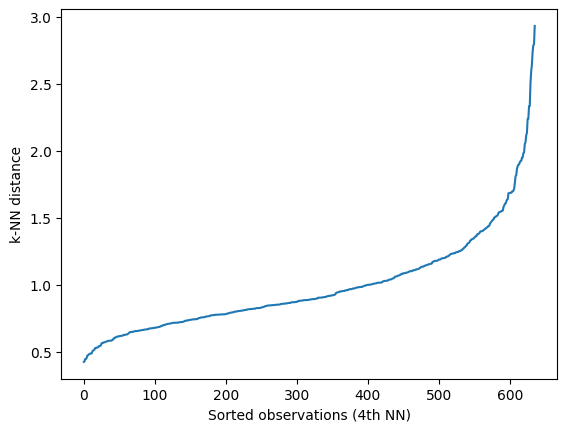

In [52]:
k_dist = sort_neigh_dist[:, 4]
plt.plot(k_dist)
plt.ylabel("k-NN distance")
plt.xlabel("Sorted observations (4th NN)")
plt.show()

* <u>Автоматичне виявлення параметра за графіком K-distance</u>

In [53]:
kneedle = KneeLocator(x = range(1, len(neigh_dist)+1), y = k_dist, S = 1.0, 
                      curve = "concave", direction = "increasing", online=True)

print(kneedle.knee_y)

2.3326314925212266


* <u>Візуалізація автоматичного виявлення</u>

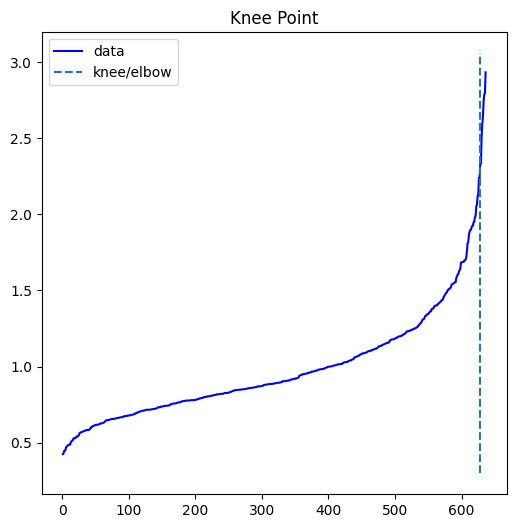

In [54]:
kneedle.plot_knee()
plt.show()

* <u>Процес передбачення кластеризації</u>

In [55]:
clusters = DBSCAN(eps = 2.33, min_samples = 4).fit_predict(tsne_em)

* <u>Зображення кількості кластерів</u>

In [56]:
set(clusters)

{np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7)}

* <u>Кількість даних на один кластер</u>

In [57]:
Counter(clusters)

Counter({np.int64(4): 221,
         np.int64(0): 176,
         np.int64(2): 85,
         np.int64(1): 58,
         np.int64(3): 37,
         np.int64(6): 34,
         np.int64(5): 13,
         np.int64(7): 11,
         np.int64(-1): 1})

* <u>Візуалізація кластерів</u>

In [58]:
cluster.tsneplot(score=tsne_em, colorlist=clusters, 
    colordot=('#713e5a', '#63a375', '#edc79b', '#d57a66', '#ca6680', '#395B50', '#92AFD7', '#b0413e', '#4381c1', '#736ced', '#631a86', '#de541e', '#022b3a', '#000000'), 
    legendpos='upper right', legendanchor=(1.15, 1))

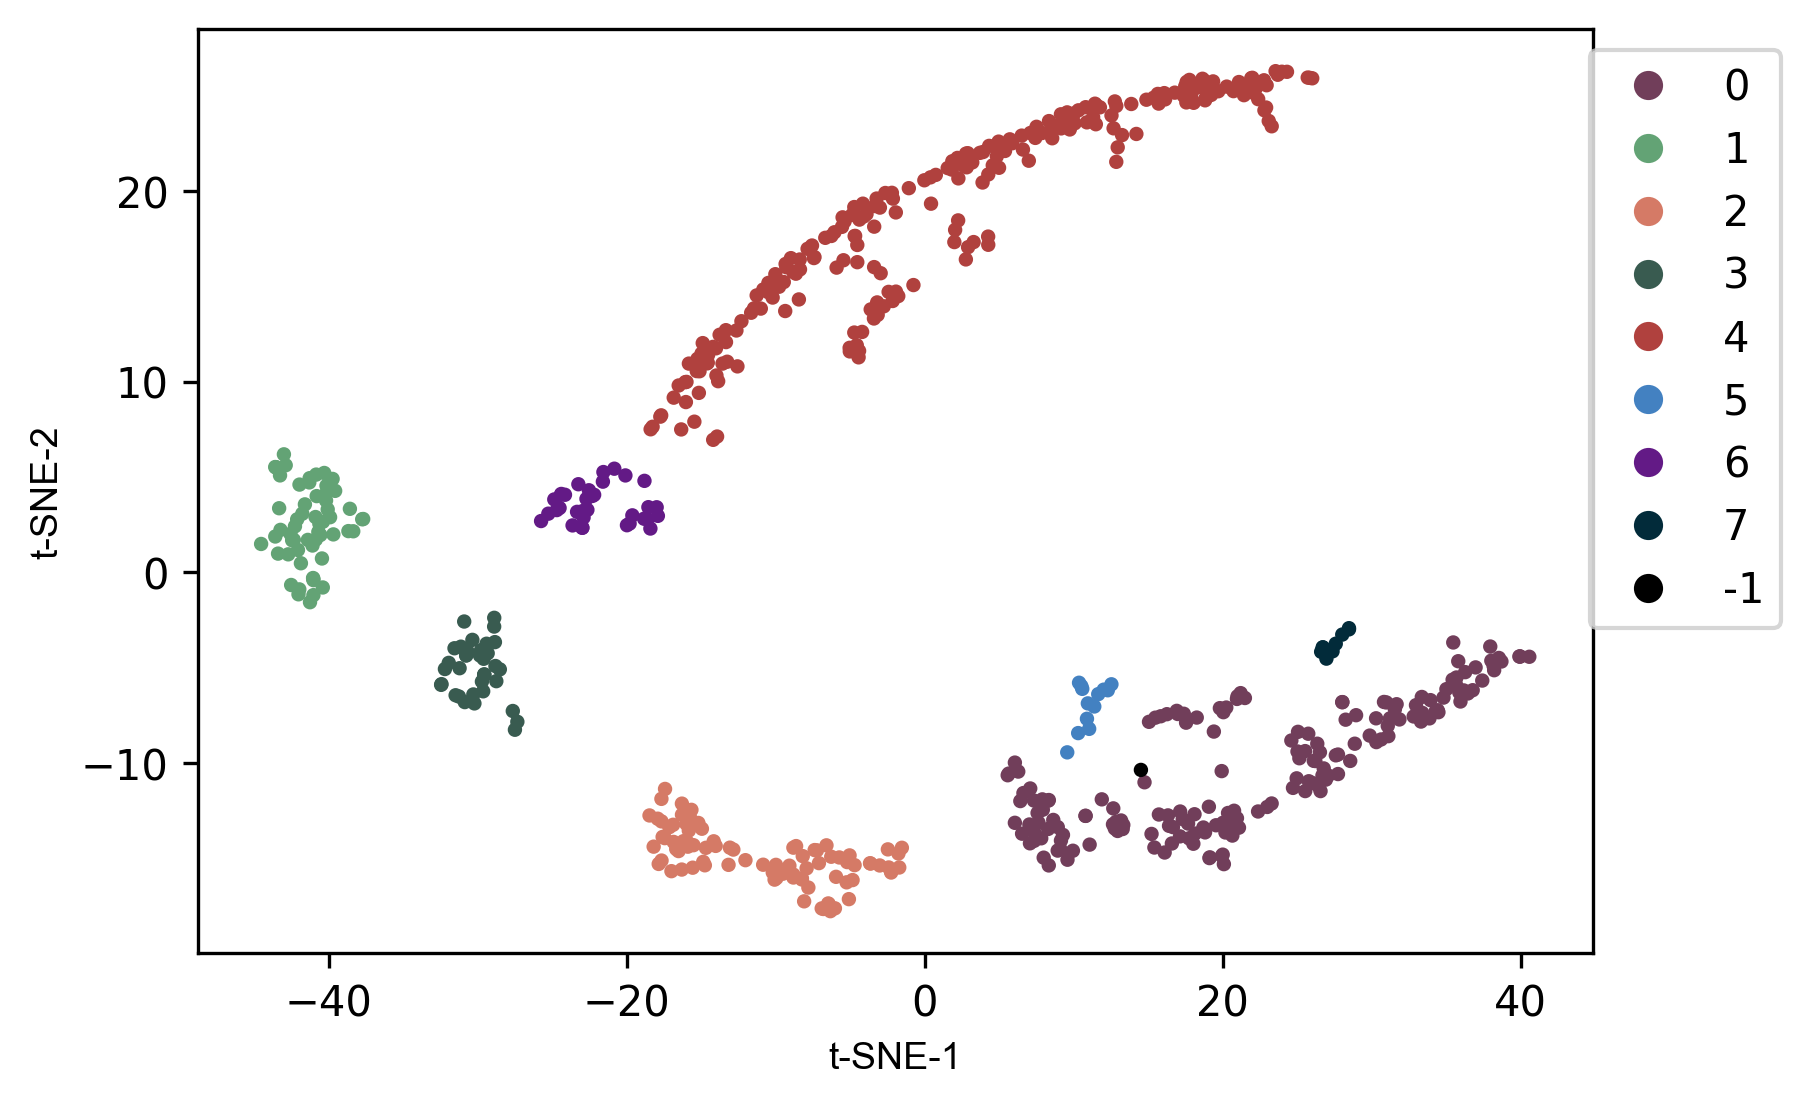

### 5. Реалізація A/B-тестування

* <u>Нова обробка даних</u>

In [9]:
df_cleaned1 = df.dropna()
df_cleaned1.shape
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
categorical_columns = df_cleaned1.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df_cleaned1.loc[:, col] = encoder.fit_transform(df_cleaned1[col])
df_cleaned1.shape

(636, 21)

* <u>Поділ вибірок для тестування та тренування</u>

In [10]:
X = df_cleaned1.drop(['Type'], axis=1)
y = df_cleaned1['Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.45, random_state=50)

* <u>Стандартизація</u>

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train) 
scaled_X_test = scaler.transform(X_test)

* <u>Вибір моделей для тестування</u>

In [29]:
model_A = LogisticRegression(solver='liblinear', max_iter=1000, C=0.1)
model_B = DecisionTreeClassifier(criterion='gini')

* <u>Тренування моделей</u>

In [30]:
model_A.fit(scaled_X_train, y_train)
model_B.fit(scaled_X_train, y_train)

DecisionTreeClassifier()

* <u>Передбачення результатів</u>

In [31]:
y_pred_A = model_A.predict(scaled_X_test)
y_pred_B = model_B.predict(scaled_X_test)

* <u>Оцінка моделей</u>

In [32]:
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return accuracy, precision, recall, f1

In [33]:
accuracy_A, precision_A, recall_A, f1_A = evaluate_model(y_test, y_pred_A)
accuracy_B, precision_B, recall_B, f1_B = evaluate_model(y_test, y_pred_B)

In [34]:
print("Model A (Logistic Regression) Performance:")
print(f"Accuracy: {accuracy_A:.4f}, Precision: {precision_A:.4f}, Recall: {recall_A:.4f}, F1-score: {f1_A:.4f}")

print("\nModel B (Decision Tree) Performance:")
print(f"Accuracy: {accuracy_B:.4f}, Precision: {precision_B:.4f}, Recall: {recall_B:.4f}, F1-score: {f1_B:.4f}")

Model A (Logistic Regression) Performance:
Accuracy: 0.9547, Precision: 1.0000, Recall: 0.4091, F1-score: 0.5806

Model B (Decision Tree) Performance:
Accuracy: 0.9965, Precision: 1.0000, Recall: 0.9545, F1-score: 0.9767


* <u>Крос-валідація моделей; виведення середньої точності та стандартного відхилення</u>

In [36]:
accuracy_A_cv = cross_val_score(model_A, X, y, cv=5, scoring='accuracy')
accuracy_B_cv = cross_val_score(model_B, X, y, cv=5, scoring='accuracy')

print("Model A (Logistic Regression) CV Accuracy: Mean = {:.4f}, Std = {:.4f}".format(accuracy_A_cv.mean(), accuracy_A_cv.std()))
print("Model B (Decision Tree) CV Accuracy: Mean = {:.4f}, Std = {:.4f}".format(accuracy_B_cv.mean(), accuracy_B_cv.std()))

Model A (Logistic Regression) CV Accuracy: Mean = 0.9309, Std = 0.0386
Model B (Decision Tree) CV Accuracy: Mean = 0.9984, Std = 0.0031


* <u>Статистичний тест</u>

In [37]:
t_stat, p_value = stats.ttest_ind(accuracy_A_cv, accuracy_B_cv)
print(f"\nT-test result for accuracy comparison: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")


T-test result for accuracy comparison: t-statistic = -3.4854, p-value = 0.0083
